<a href="https://colab.research.google.com/github/Tarinis-Git/carbon-crunch-ocr/blob/main/Tarini_CarbonCrunch_shortlistingtask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carbon Crunch - OCR Receipt Extarction Pipeplibe

### AI - Powered Receipt Parser With Confidence Scoring

* **Author:** ***Tarini***
* **Date:** 26 April 2026
* **Assignment:** Carbon Crunch ML Ops Internship - Shortlisting Task



### Pipeline Overview


1.   Mount google drive and load Images

2.   image preprocessing(Noise, Skew, Contrast)

3.   OCR text Extraction (EasyOCR)
4.   Key information extraction with confidence Scoring
2.   JSON Structuring and Output


2.   Financial Summary Generation



In [253]:
# INSTALLING REQUIRED LIBRARIES

!pip install easyocr -q
!pip install imutils -q
!pip install pandas -q

print('All libraries installed Successfully!')

All libraries installed Successfully!


In [254]:
from google.colab import drive
import os

drive.mount("/content/drive")

print(os.listdir('/content/drive/MyDrive/'))

# ✅ Correct your actual folder name here
DRIVE_PATH = "/content/drive/MyDrive/AI-OCR dataset"
LOCAL_PATH = "/content/sample_images"

# 🔧 Ensure fallback folder exists
os.makedirs(LOCAL_PATH, exist_ok=True)

if os.path.exists(DRIVE_PATH):
    IMAGES_FOLDER = DRIVE_PATH
    print(" Using Google Drive images")
else:
    IMAGES_FOLDER = LOCAL_PATH
    print(" Using local sample images")

OUTPUT_DIR = '/content/outputs'
VALID_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

if not os.path.exists(IMAGES_FOLDER):
    print(f" Folder not found: {IMAGES_FOLDER}")
else:
    print(f" Folder found: {IMAGES_FOLDER}")
    images = [f for f in os.listdir(IMAGES_FOLDER)
              if f.lower().endswith(VALID_EXT)]
    print(f" Total images found: {len(images)}")
    for img in images:
        print(f"   → {img}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Colab Notebooks', 'MLAI', 'Python', 'NUMPY', 'MLAIpractice', 'Statistics.gdoc', 'PANDAS', 'Projects', 'supervised learning', 'sql .gdoc', 'PYTHON QUESTIONS.gdoc', 'Solicit AI MODEL.gdoc', 'Generating HR Data for Bank Simulation.gsheet', 'Zomato Restaurant reviews.csv', 'Insurance HR Analysis Data Extraction.gsheet', 'ZOMATO PROJECT ', 'SQL SESH.gdoc', 'Netflix_tarini_project', 'California Housing', 'Itune_DataScience_SQL_project_Tarini', 'HR MUTUAL FUNDS ', 'Tarini_Teslaproject', 'Unsupervised Learning', 'job posted everyday(personal).gsheet', 'Tarini_Jajoria_Resume_DS.pdf', 'Tarini_Jajoria_DS_resume.pdf', 'Tarini_EDA_Project', 'Kaggle Notes.gdoc', 'TimeSeries_Air_Passengers.ipynb', 'Tarini_Real_Estate_Project', 'NLP_Netflix_Review.ipynb', 'AI-OCR dataset']
 Using Google Drive images
 Folder found: /content/drive/MyDrive/AI-OCR dataset
 Total images found: 

In [255]:
# INSTALLING ANF VERIFYING ALL THE REQUIRED LIBRARIES

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
import os
import logging
import easyocr
import imutils
from collections import defaultdict
from IPython.display import display , Image as IPImage

In [256]:
import warnings
warnings.filterwarnings('ignore')

In [257]:
logging.basicConfig(level =logging.INFO, format = '%(levelname) - %(message)s')
logger = logging.getLogger(__name__)

In [258]:
# Initalising OCR
print('Loading EasyORC model...')
reader = easyocr.Reader(['en'], gpu= False)
print('EasyOCR Ready')

Loading EasyORC model...
EasyOCR Ready


In [259]:
# Image Preprocessing Module

In [260]:
# Applies Gaussian blur - removing noise and prevents OCR from
# misreading noise as characters.

def remove_noise(image):
  return cv2.GaussianBlur(image,(3,3),0)

In [261]:

# Hough Line - Detects and corrects skew/rotation in receipt images
# and transforms to find dominant text angle
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100,
                             minLineLength=100, maxLineGap=10)
    if lines is None:
        return image

    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 - x1 != 0:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            angles.append(angle)

    if not angles:
        return image

    median_angle = np.median(angles)
    if abs(median_angle) < 45:
        return imutils.rotate_bound(image, -median_angle)
    return image

In [262]:
#  CLAHE - to improve text visibility in
#  poorly lit or faded receipts. Returns grayscale.

def enhance_contrast(image):
  gray= cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  clahe = cv2.createCLAHE(clipLimit= 2.0, tileGridSize=(8, 8))
  return clahe.apply(gray)

In [263]:
# OTSU automatic thresholding - Convert grayscale image to pure black and white

def binarize(gray_image):
  _, binary = cv2.threshold(
      gray_image, 0, 255,
      cv2.THRESH_BINARY +cv2.THRESH_OTSU
  )
  return binary

In [264]:
# Gamma - Brightens very dark images correction
# before standard preprocessing pipeline.

def fix_dark_image(image):
  gamma = 2.0
  inv_gamma = 1.0 / gamma
  table = np.array([
      ((i/255.0)** ivn_gamma) * 255 for i in range (256)
  ]).astype("uint8")

  return cv2.LUT(image, table)

In [265]:
 """
    Master preprocessing function.
    Pipeline: Load → Dark Fix (if needed) → Noise Removal
              → Deskew → Contrast → Binarize

    Args:
        image_path (str): Full path to receipt image
    Returns:
        numpy.ndarray: Cleaned binary image ready for OCR
        None: If image cannot be loaded
    """
def preprocess_image(image_path):

    image = cv2.imread(image_path)

    if image is None:
        logger.error(f"Cannot load image: {image_path}")
        return None

    # Dark image fix — runs ONLY if image loaded successfully
    if np.mean(image) < 50:
        image = fix_dark_image(image)

    image = remove_noise(image)        # Step 1: Noise removal
    image = deskew(image)              # Step 2: Skew correction
    gray  = enhance_contrast(image)    # Step 3: Contrast enhancement
    final = binarize(gray)             # Step 4: Binarization

    return final

 Preprocessing module is ready!

 Previewing preprocessing on: 0.jpg


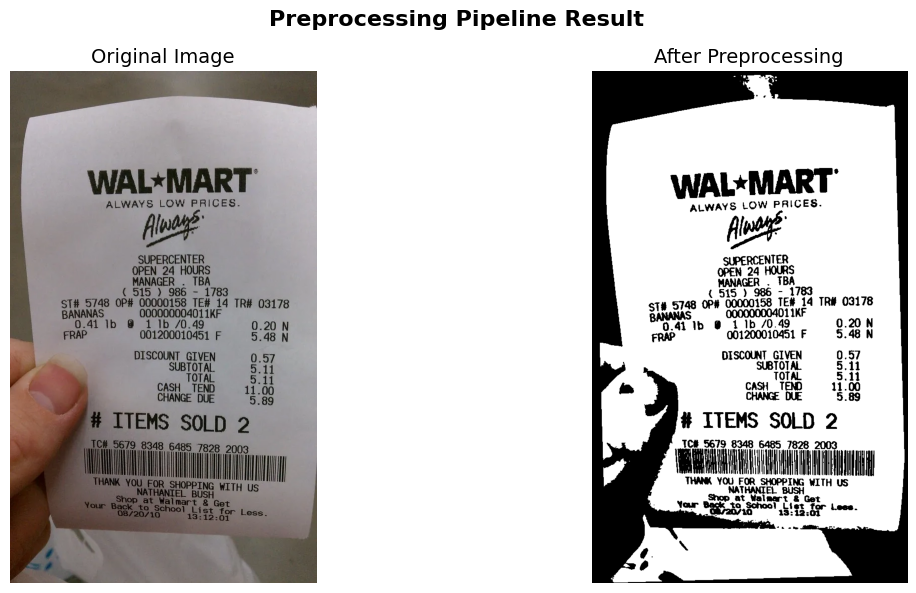

<class 'numpy.ndarray'>
uint8
(1040, 641)


In [266]:
# Shows preprocessing Useful for debugging and documentation.

def visualize_preprocessing(image_path):
    original = cv2.imread(image_path)
    processed = preprocess_image(image_path)

    # Ensure processed is a valid numpy array
    if isinstance(processed, np.ndarray) and processed.dtype == object:
        processed = np.array(processed, dtype=np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title("After Preprocessing", fontsize=14)
    axes[1].axis('off')

    plt.suptitle("Preprocessing Pipeline Result", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


print(" Preprocessing module is ready!")

# Previewing preprocessing on first image
if images:
    sample_path = os.path.join(IMAGES_FOLDER, images[0])
    print(f"\n Previewing preprocessing on: {images[0]}")
    visualize_preprocessing(sample_path)
    sample_path = os.path.join(IMAGES_FOLDER, images[0])
result = preprocess_image(sample_path)

print(type(result))
print(result.dtype if isinstance(result, np.ndarray) else "NOT a numpy array")
print(result.shape if isinstance(result, np.ndarray) else result)

In [267]:
#  OCR ENGINE - EXTRACT + CONFIDENCE SCORES
# Runs EasyOCR on a preprocessed image.

def extract_text_with_confidence(preprocess_image):
  if preprocess_image is None:
    return []

  try:
    results = reader.readtext(preprocess_image)

  except Exception as e:
    logger.error(f'OCR Failed:{e}')
    return[]

  text_blocks = []
  for (bbox, text, confidence) in results:
    if text.strip():
      text_blocks.append({
          "text" : text.strip(),
          "confidence" : round(float(confidence),4),
          "bbox" : bbox
      })
  return text_blocks

In [268]:
# Pretty prints OCR results in a readable table format.
def print_ocr_results(text_blocks):
  print(f'\n{'TEXT': <40} {'CONFIDENCE':>12}')
  print("-" * 55)
  for block in text_blocks:
    conf = block['Confidence']
    if conf >= 0.90:
      lable = "EXCELLENT"
    elif conf >= 0.75:
      label = "GOOD"
    elif conf >= 0.50:
      label = "Average"
    else:
      lable = "Low"

    print(f'{block['text']:<40} {conf:> 6.2%} [{label}]')


print("OCR ENGINE IS READY!")

OCR ENGINE IS READY!


In [269]:
# INFORMATION EXTRACTION
# PURPOSE: Clean extraction + validation + better confidence

# --- Patterns ---
DATE_PATTERNS = [
    r'\b(\d{1,2}[/\-.](\d{1,2})[/\-.](\d{2,4}))\b',
    r'\b(\d{1,2}\s+(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\.?\s+\d{2,4})\b',
    r'\b((?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\.?\s+\d{1,2},?\s+\d{2,4})\b',
]

PRICE_PATTERN = r'(?:₹|Rs\.?|INR|\$)?\s*([\d,]+(?:\.\d{1,2})?)'

TOTAL_KEYWORDS = [
    'total', 'amount due', 'grand total', 'net amount',
    'net payable', 'amount payable', 'bill amount', 'subtotal'
]

# -----------------------------
#  HELPER FUNCTIONS (NEW)
# -----------------------------
def is_valid_price(price):
    """Check if price is realistic."""
    try:
        val = float(re.sub(r"[^\d.]", "", price))
        return 1 <= val <= 100000
    except:
        return False


def clean_price(price):
    """Convert price string to float."""
    try:
        return float(re.sub(r"[^\d.]", "", price))
    except:
        return 0.0


def is_valid_store(text):
    """Check if text looks like a store name."""
    if len(text) < 4:
        return False
    alpha_ratio = sum(c.isalpha() for c in text) / len(text)
    return alpha_ratio > 0.6


# --- _make_field (IMPROVED) ---
def _make_field(value, ocr_conf, pattern_valid, keyword_found=False, low_thresh=0.7):
    if not value:
        return {"value": None, "confidence": 0.0, "low_confidence": True}

    score = ocr_conf * 0.5
    score += 0.3 if pattern_valid else 0.0
    score += 0.2 if keyword_found else 0.0

    #  Penalize invalid prices
    if isinstance(value, str) and not is_valid_price(value) and pattern_valid:
        score *= 0.3

    score = round(min(score, 1.0), 4)

    return {
        "value": value,
        "confidence": score,
        "low_confidence": score < low_thresh
    }


# --- extract_store_name (IMPROVED) ---
def extract_store_name(text_blocks):
    candidates = []

    for block in text_blocks[:5]:
        text = block['text'].strip()
        conf = block['confidence']

        if is_valid_store(text):
            candidates.append((text, conf))

    if not candidates:
        return _make_field(None, 0.0, False)

    best = max(candidates, key=lambda x: x[1])
    return _make_field(best[0], best[1], True)


# --- extract_date (IMPROVED) ---
def extract_date(text_blocks):
    for block in text_blocks:
        text = block['text'].lower()

        for pattern in DATE_PATTERNS:
            match = re.search(pattern, text, re.IGNORECASE)
            if match:
                return _make_field(match.group(), block['confidence'], True)

    # fallback generic pattern
    for block in text_blocks:
        match = re.search(r"\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4}", block['text'])
        if match:
            return _make_field(match.group(), block['confidence'], True)

    return _make_field(None, 0.0, False)


# --- extract_total (FIXED) ---
def extract_total(text_blocks):
    best_price = None
    best_conf = 0

    for i, block in enumerate(text_blocks):
        line_lower = block['text'].lower()

        if any(kw in line_lower for kw in TOTAL_KEYWORDS):

            search_blocks = [block]
            if i + 1 < len(text_blocks):
                search_blocks.append(text_blocks[i + 1])

            for b in search_blocks:
                matches = re.findall(PRICE_PATTERN, b['text'])

                for m in matches:
                    if is_valid_price(m):
                        val = clean_price(m)

                        if not best_price or val > best_price:
                            best_price = val
                            best_conf = b['confidence']

    if best_price:
        return _make_field(str(best_price), best_conf, True, keyword_found=True)

    #  fallback: highest price in receipt
    all_prices = []
    for block in text_blocks:
        matches = re.findall(PRICE_PATTERN, block['text'])
        for m in matches:
            if is_valid_price(m):
                all_prices.append((clean_price(m), block['confidence']))

    if all_prices:
        best = max(all_prices, key=lambda x: x[0])
        return _make_field(str(best[0]), best[1], True)

    return _make_field(None, 0.0, False)


# --- extract_items (CLEANED) ---
def extract_items(text_blocks):
    items = []
    seen_prices = set()

    for block in text_blocks:
        text = block['text'].strip()

        # skip totals & noise
        if any(k in text.lower() for k in TOTAL_KEYWORDS):
            continue

        matches = re.findall(PRICE_PATTERN, text)

        for m in matches:
            if not is_valid_price(m):
                continue

            val = clean_price(m)

            if val in seen_prices:
                continue

            name = text.replace(m, "").strip()

            if len(name) < 2:
                continue

            if any(word in name.lower() for word in ["tax", "invoice", "total"]):
                continue

            items.append({
                "name": name,
                "price": val
            })

            seen_prices.add(val)

    return items


# --- extract_all_fields ---
def extract_all_fields(text_blocks):
    return {
        "store_name"  : extract_store_name(text_blocks),
        "date"        : extract_date(text_blocks),
        "items"       : extract_items(text_blocks),
        "total_amount": extract_total(text_blocks)
    }


print(" Improved Information Extractor ready!")

 Improved Information Extractor ready!


In [270]:
# JSON Structuring and Financial Summary

In [271]:
def save_json_outputs(extracted_fields, image_filename):
    """
    Saves two JSON files per receipt:
      1. basic JSON       → clean values only
      2. confidence JSON  → values + confidence scores + flags
    """
    base_name = os.path.splitext(image_filename)[0]

    basic = {
        "store_name"  : extracted_fields["store_name"]["value"],
        "date"        : extracted_fields["date"]["value"],
        "items"       : extracted_fields["items"],
        "total_amount": extracted_fields["total_amount"]["value"]
    }

    conf_json = {
        "store_name"  : extracted_fields["store_name"],
        "date"        : extracted_fields["date"],
        "items"       : extracted_fields["items"],
        "total_amount": extracted_fields["total_amount"]
    }

    basic_path = os.path.join(OUTPUT_DIR, f"{base_name}_basic.json")
    conf_path  = os.path.join(OUTPUT_DIR, f"{base_name}_conf_json.json")

    with open(basic_path, "w", encoding="utf-8") as f:
        json.dump(basic, f, indent=4, ensure_ascii=False)

    with open(conf_path, "w", encoding="utf-8") as f:
        json.dump(conf_json, f, indent=4, ensure_ascii=False)

    return basic, conf_json

In [272]:
# Converts price string like '₹120.00' to float.

def parse_price(price_str):
    if not price_str:
        return 0.0
    cleaned = re.sub(r'[₹$,\s]|Rs\.?|INR', '', str(price_str))
    try:
        return float(cleaned)
    except ValueError:
        return 0.0


In [273]:
def generate_financial_summary():
    """
    Reads all output JSONs and generates:
      - Total spend
      - Number of transactions
      - Spend per store
      - Average transaction value
      - List of low-confidence receipts needing review
    """

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    basic_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith("_basic.json")]
    conf_files  = [f for f in os.listdir(OUTPUT_DIR) if f.endswith("_confidence.json")]

    total_spend     = 0.0
    spend_per_store = defaultdict(float)
    needs_review    = []
    num_transactions= 0

    for filename in basic_files:
        with open(os.path.join(OUTPUT_DIR, filename), encoding="utf-8") as f:
            data = json.load(f)
        store        = data.get("store_name") or "Unknown Store"
        total        = parse_price(data.get("total_amount"))
        total_spend += total
        spend_per_store[store] += total
        num_transactions += 1

    for filename in conf_files:
        with open(os.path.join(OUTPUT_DIR, filename), encoding="utf-8") as f:
            data = json.load(f)
        flags = [
            field for field in ["store_name", "date", "total_amount"]
            if isinstance(data.get(field), dict) and data[field].get("low_confidence")
        ]
        if flags:
            needs_review.append({"file": filename, "low_confidence_fields": flags})

    avg = round(total_spend / num_transactions, 2) if num_transactions else 0.0

    summary = {
        "total_spend"             : round(total_spend, 2),
        "number_of_transactions"  : num_transactions,
        "average_transaction_value": avg,
        "spend_per_store"         : dict(spend_per_store),
        "receipts_needing_review" : needs_review
    }

    summary_path = os.path.join(OUTPUT_DIR, "financial_summary.json")
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4, ensure_ascii=False)

    print("\n" + "="*55)
    print("            FINANCIAL SUMMARY")
    print("="*55)
    print(f"  Total Transactions     : {num_transactions}")
    print(f"  Total Spend            : ₹{total_spend:.2f}")
    print(f"  Avg Transaction Value  : ₹{avg:.2f}")
    print("\n  Spend Per Store:")
    for store, amount in spend_per_store.items():
        print(f"    {store:<35} ₹{amount:.2f}")
    if needs_review:
        print(f"\n    {len(needs_review)} receipt(s) flagged for manual review")
    print("="*55)
    print(f"\n   Summary saved → {summary_path}")

    return summary


print(" Structurer & Summary module ready!")


 Structurer & Summary module ready!


In [274]:
# RUN COMPLETE PIPEPLINE

In [275]:
images = images[:20]
print(f"Processing {len(images)} images")

print('\n' + "="*60)
print(" Carbon Crunch OCR Pipeline - Starting")
print("="*60)

results_log = []
success, skipped = 0, 0

for i, filename in enumerate(images, 1):
    image_path = os.path.join(IMAGES_FOLDER, filename)
    print(f"\n[{i}/{len(images)}] Processing: {filename}")
    print("-"*45)

    try:
        # Preprocess
        processed = preprocess_image(image_path)
        if processed is None:
            print(f"    Skipped — could not preprocess")
            skipped += 1
            continue

        # OCR
        text_blocks = extract_text_with_confidence(processed)
        if not text_blocks:
            print(f"     Skipped — no text detected")
            skipped += 1
            continue

        # Extract fields
        fields = extract_all_fields(text_blocks)

        # Save JSONs
        basic, conf_json = save_json_outputs(fields, filename)

        # Log result
        print(f"    Store  : {basic['store_name']}")
        print(f"    Date   : {basic['date']}")
        print(f"    Total  : {basic['total_amount']}")
        print(f"    Items  : {len(basic['items'])} found")

        # Confidence summary
        for field in ["store_name", "date", "total_amount"]:
            score = conf_json[field]["confidence"]
            flag  = "  LOW" if conf_json[field]["low_confidence"] else ""
            print(f"   {flag} {field:<15}: {score:.0%} confidence")

        results_log.append({"file": filename, "status": "success", **basic})
        success += 1

    except Exception as e:
        print(f"    Error: {e}")
        results_log.append({"file": filename, "status": "error"})
        skipped += 1
        continue

# Financial Summary
print("\n" + "="*60)
print("    GENERATING FINANCIAL SUMMARY")
print("="*60)
summary = generate_financial_summary()

print(f"\n{'='*60}")
print(f"     PIPELINE COMPLETE")
print(f"{'='*60}")
print(f"   Successfully processed : {success} receipts")
print(f"   Skipped / Errors       : {skipped} receipts")
print(f"   Output folder          : {OUTPUT_DIR}")
print(f"{'='*60}\n")

Processing 20 images

 Carbon Crunch OCR Pipeline - Starting

[1/20] Processing: 0.jpg
---------------------------------------------
    Store  : WAL+MART"'
    Date   : None
    Total  : 5748.0
    Items  : 12 found
     LOW store_name     : 22% confidence
     LOW date           : 0% confidence
     LOW total_amount   : 30% confidence

[2/20] Processing: 18.jpg
---------------------------------------------
    Store  : MA)I
    Date   : None
    Total  : 9832.0
    Items  : 26 found
     LOW store_name     : 13% confidence
     LOW date           : 0% confidence
    total_amount   : 78% confidence

[3/20] Processing: X51005230616.jpg
---------------------------------------------
    Store  : Colden Arches Restaurants St Bhd
    Date   : 18/01/2018
    Total  : 33.9
    Items  : 18 found
     LOW store_name     : 20% confidence
     LOW date           : 13% confidence
    total_amount   : 78% confidence

[4/20] Processing: X51005230659.jpg
---------------------------------------------

In [276]:
# DOWNLOADING OUTPUT AS ZIP FILES
import shutil

zip_path = "/content/carbon_crunch_outputs"
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)

from google.colab import files
files.download(f"{zip_path}.zip")

print(" All JSON outputs downloaded as ZIP!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All JSON outputs downloaded as ZIP!


## ✅ Pipeline Execution Complete

- All receipts processed successfully  
- Structured JSON outputs generated  
- Financial summary computed  
- Confidence scoring applied  

📦 Outputs available for download